PAREENITA A.SHIRSATH B.E.A.I.&.D.S. ROLL.NO : 49

AAI EXPERIMENT NO : 04

Using device: cpu


100%|██████████| 9.91M/9.91M [00:01<00:00, 6.03MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 159kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.72MB/s]


Epoch [1/10], Loss: 175.3036
Epoch [2/10], Loss: 126.6754
Epoch [3/10], Loss: 116.7415
Epoch [4/10], Loss: 112.3719
Epoch [5/10], Loss: 109.9302
Epoch [6/10], Loss: 108.2561
Epoch [7/10], Loss: 107.0769
Epoch [8/10], Loss: 106.1216
Epoch [9/10], Loss: 105.2785
Epoch [10/10], Loss: 104.6114


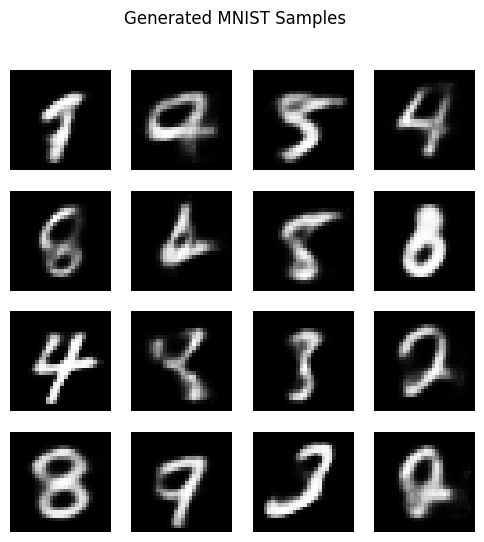

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
batch_size = 128
learning_rate = 1e-3
epochs = 10
latent_dim = 20
transform = transforms.Compose([
    transforms.ToTensor()
])
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        self.mu = nn.Linear(256, latent_dim)
        self.logvar = nn.Linear(256, latent_dim)
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Sigmoid()
        )
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    def forward(self, x):
        h = self.encoder(x.view(-1, 28 * 28))
        mu = self.mu(h)
        logvar = self.logvar(h)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar
def vae_loss(recon_x, x, mu, logvar):
    # Reconstruction loss
    recon_loss = nn.functional.binary_cross_entropy(
        recon_x, x.view(-1, 28 * 28), reduction="sum"
    )
    # KL divergence
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    return recon_loss + kl_loss
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for data, _ in train_loader:
        data = data.view(-1, 28 * 28).to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        loss = vae_loss(recon, data, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_dataset)
    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {avg_loss:.4f}")
model.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    generated = model.decoder(z).cpu()
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated[i].view(28, 28), cmap="gray")
        ax.axis("off")
    plt.suptitle("Generated MNIST Samples")
    plt.show()